# Tarea 1 — Física estadística y evolución térmica del Universo



**Asignatura:** Cosmología   
**Objetivo general:** construir, mediante cálculos numéricos y gráficos, una descripción de la evolución térmica del Universo desde el régimen relativista hasta la nucleosíntesis primordial.




## 🧭 Organización de la tarea

| Bloque | Tema | Producto principal |
|---|---|---|
| I | Expansión cosmológica | $\rho_i(a)$, $\rho_i(z)$ |
| II | Historia del Universo | igualdad materia-radiación y CMB |
| III | Distribuciones estadísticas | BE, FD y MB |
| IV | Radiación térmica | espectro de Planck y CMB |
| V | Electrones y positrones | $n_{e^\pm}/n_\gamma$ |
| VI | Grados de libertad | $g_*(T)$, $g_{*s}(T)$ |
| VII | Desacoplamiento | $\Gamma/H$ y $T_{\rm dec}$ |
| VIII | Neutrinos y entropía | $T_\nu/T_\gamma$ |
| IX | Neutrones y protones | $n/p$, $q(T)$ |
| X | Tiempo cosmológico | $t(T)$ y decaimiento del neutrón |
| XI | Nucleosíntesis | estimación de $Y_p$ |
| XII | Síntesis | conectar toda la cadena física |



In [1]:
# ============================================================
# Constantes y conversión de Unidades a usar
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Constantes SI
h = 6.62607015e-34          # J s
hbar = 1.054571817e-34      # J s
kB = 1.380649e-23           # J/K
c = 299792458.0             # m/s

# Constantes cosmológicas / físicas
G = 6.67430e-11             # m^3 kg^-1 s^-2
Mpc = 3.085677581491367e22  # m

# Constantes útiles en física de partículas
eV_J = 1.602176634e-19
MeV_J = 1e6 * eV_J
GeV_J = 1e9 * eV_J

# Conversión de unidades naturales
hbar_GeVs = 6.582119569e-25  # GeV s
Mpl_GeV = 1.2209e19          # Planck mass (no reducida)
G_F = 1.1663787e-5           # GeV^-2

# Temperatura actual del CMB
T0 = 2.7255                  # K

# I. Expansión cosmológica

¿Cómo cambia la densidad de las distintas componentes cuando cambia el factor de escala?.

Para una componente con ecuación de estado

$$
p=w\rho c^2,
$$

la ecuación de conservación implica

$$
\rho(a)\propto a^{-3(1+w)}.
$$

Por tanto:

$$
\boxed{\rho_m\propto a^{-3}}
$$

para materia no relativista,

$$
\boxed{\rho_r\propto a^{-4}}
$$

para radiación, y

$$
\boxed{\rho_\Lambda=\text{constante}}
$$

para una constante cosmológica.

## Ejercicio 1 — Componentes del Universo

Utilizando los valores: 

$$
\rho_{r,0}=4.6\times10^{-31}+3.2\times10^{-31}\ {\rm kg\,m^{-3}},
$$

$$
\rho_{m,0}=4.2\times10^{-28}+2.3\times10^{-27}\ {\rm kg\,m^{-3}},
$$

$$
\rho_{\Lambda,0}=5.9\times10^{-27}\ {\rm kg\,m^{-3}}.
$$

1. Defina $a$ desde $10^{-8}$ hasta $1$.
2. Construya $\rho_r(a)$, $\rho_m(a)$ y $\rho_\Lambda(a)$.
3. Grafícalas en una sola figura con `plt.loglog()`.
4. Identifica visualmente qué componente domina en cada época.
5. Explica por qué la radiación cae más rápidamente que la materia.


In [2]:
a = np.linspace(1e-8, 1, 10000)
# Valores de las densidades
rho_lam = 5.9e-27
rho_mat = 4.43e-28
rho_rad = 7.8e-31
# Evolución de las densidades en función de a
rholam = (5.9e-27 + a * 0) / rho_lam
rhor = rho_rad * a ** (- 4) / rho_lam
rhom = rho_mat * + a ** (- 3) / rho_lam
# Cálculo de los puntos en que la jerarquía de densidades cambia
rad_age =  rho_rad / rho_mat # Cambio a dominación por materia rho_m = rho_r
mat_age = (rho_mat / rho_lam) ** (1 / 3) # Cambio a dominación por materia oscura rho_m = rho_lamb


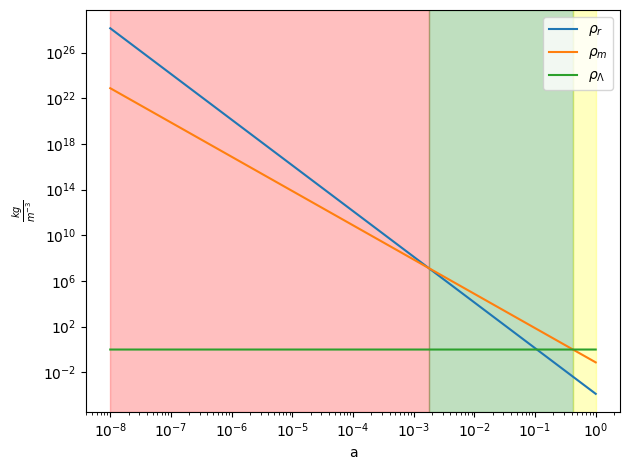

In [10]:
plt.loglog(a, rhor, label = r'$\rho_r$')
plt.loglog(a, rhom, label = r'$\rho_m$')
plt.loglog(a, rholam, label = r'$\rho_\Lambda$')
plt.legend(loc = 'upper right')
plt.axvspan(a[0], rad_age, color = 'red', alpha = 0.25) # Zona donde domina la radiación (rojo)
plt.axvspan(rad_age, mat_age, color = 'green', alpha = 0.25) # Zona donde domina la materia (verde)
plt.axvspan(mat_age, a[-1], color = 'yellow', alpha = 0.25) # Zona donde domina la materia oscura (amarillo)
plt.xlabel('a')
plt.ylabel(r'$\frac{kg}{m^{-3}}$')
plt.tight_layout()
plt.show()

## Ejercicio 2 — Igualdad materia–radiación

La igualdad materia–radiación ocurre cuando

$$
\rho_r(a_{\rm eq})=\rho_m(a_{\rm eq}).
$$

Demuestra algebraicamente que

$$
a_{\rm eq}=\frac{\rho_{r,0}}{\rho_{m,0}}.
$$

Usando

$$
a=\frac{1}{1+z},
$$

obtén

$$
\boxed{
1+z_{\rm eq}=\frac{\rho_{m,0}}{\rho_{r,0}}
}.
$$

### Entregables

- $a_{\rm eq}$
- $z_{\rm eq}$
- una comprobación numérica de que $\rho_r(a_{\rm eq})=\rho_m(a_{\rm eq})$.

# Solución:
Usando las expresiones:
- $$\rho_r(a) = \rho_{r0} a^{-4}$$
- $$\rho_m(a) = \rho_{m0} a ^{-3}$$
En el punto de equilibrio:
$$\rho_{r0} a_{eq} ^{-4} = \rho_{m0} a_{eq} ^{-3}$$
Despejando $a_{eq}$:
$$\frac{\rho_{r0}}{\rho_{m0}} = a_{eq} = \frac{1}{1 + z_{eq}}$$
$$\rightarrow \frac{\rho_{m0}}{\rho_{r0}} = 1 + z_{eq}$$
Ahora, usando los valores definidos anteriormente, se puede realizar la comprobación:

# II. La historia del Universo en función del redshift

El redshift cosmológico es

$$
1+z=\frac{1}{a}.
$$

Por tanto,

$$
\rho_r(z)=\rho_{r,0}(1+z)^4,
$$

$$
\rho_m(z)=\rho_{m,0}(1+z)^3,
$$

$$
\rho_\Lambda(z)=\rho_{\Lambda,0}.
$$


## Ejercicio 3 — Composición del Universo

Construye una figura de $\rho(z)$ en escala logarítmica, con $10^{-2}\lesssim z\lesssim10^8$.

Marca con líneas verticales:

- igualdad materia–radiación;
- recombinación/CMB, $z_{\rm CMB}\simeq1100$;
- $a=1$, es decir $z=0$, si tu representación lo permite.

### Preguntas

1. ¿Qué componente domina a $z\gg z_{\rm eq}$?
2. ¿Qué componente domina entre $z_{\rm eq}$ y el comienzo de la dominación de energía oscura?
3. ¿Por qué la energía oscura no domina en el Universo temprano?
4. ¿Qué pendiente esperas para materia y radiación en una gráfica $\log\rho$ vs. $\log(1+z)$?

In [16]:
z = np.linspace(1e-2, 1e8, 100000)
rho_r = (rho_rad * (1 + z) ** 4) / rho_lam
rho_m = (rho_mat * (1 + z) ** 3) / rho_lam
rho_l = (rho_lam + z * 0) / rho_lam

[]

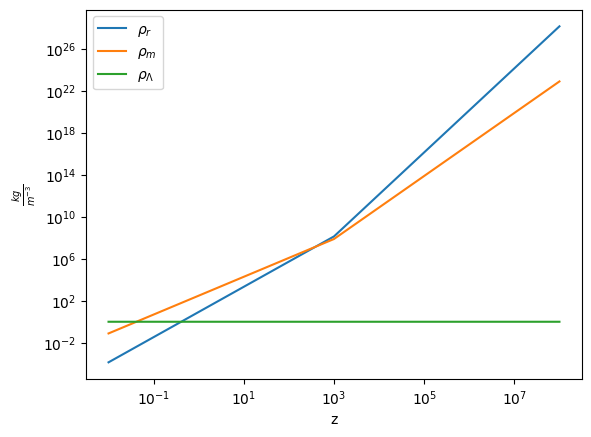

In [17]:
plt.loglog(z, rho_r, label = r'$\rho_r$')
plt.loglog(z, rho_m, label = r'$\rho_m$')
plt.loglog(z, rho_l, label = r'$\rho_\Lambda$')
plt.xlabel('z')
plt.ylabel(r'$\frac{kg}{m^{-3}}$')
plt.legend()
plt.plot()

# III. Distribuciones estadísticas: BE, FD y MB

A partir de aquí pasamos de una descripción macroscópica a una descripción microscópica.

Para una especie en equilibrio:

### Bose–Einstein

$$
f_{\rm BE}(E)=
\frac{1}{e^{(E-\mu)/k_BT}-1}.
$$

### Fermi–Dirac

$$
f_{\rm FD}(E)=
\frac{1}{e^{(E-\mu)/k_BT}+1}.
$$

### Maxwell–Boltzmann

$$
f_{\rm MB}(E)=
e^{-(E-\mu)/k_BT}.
$$

Para $E-\mu\gg k_BT$, las distribuciones cuánticas se aproximan a Maxwell–Boltzmann.

No necesitas volver a derivar estas funciones: debes utilizarlas.

## Ejercicio 4 — ¿Cuándo funciona Maxwell–Boltzmann?

Define la variable adimensional

$$
x=\frac{E-\mu}{k_BT}.
$$

Grafica en una misma figura:

$$
f_{\rm BE}(x),\qquad f_{\rm FD}(x),\qquad f_{\rm MB}(x).
$$

### Analiza

1. ¿Qué ocurre cuando $x\gg1$?
2. ¿Qué ocurre cuando $x\sim1$?
3. ¿Por qué Maxwell–Boltzmann no puede describir correctamente la radiación del CMB?
4. ¿Por qué sí resulta útil para partículas suficientemente no relativistas y diluidas?

In [5]:
x = np.linspace(1, 100, 10000)
BE = 1 / (np.exp(x) - 1)
FD = 1 / (np.exp(x) + 1)
MB = np.exp(-x)

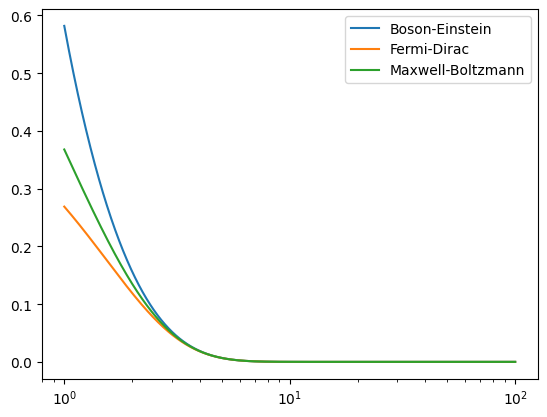

In [7]:
plt.semilogx(x, BE, label = 'Boson-Einstein')
plt.semilogx(x, FD, label = 'Fermi-Dirac')
plt.semilogx(x, MB, label = 'Maxwell-Boltzmann')
plt.legend()
plt.show()

# IV. Fotones y el espectro del CMB

Los fotones son bosones con dos estados de polarización:

$$
\boxed{g_\gamma=2}.
$$

Además, el número de fotones no se conserva en equilibrio térmico, por lo que para el CMB usamos

$$
\mu_\gamma=0.
$$

La distribución de ocupación es

$$
f_\gamma(E)=\frac{1}{e^{E/k_BT}-1}.
$$

A partir de ella se obtiene la ley de Planck:

$$
\boxed{
B_\nu(T)=
\frac{2h\nu^3}{c^2}
\frac{1}{e^{h\nu/k_BT}-1}
}.
$$

Esta es una de las conexiones más importantes entre física estadística y cosmología observacional.

## Ejercicio 5 — Espectro de Planck del CMB

Usa

$$
T_{\rm CMB}=2.7255\ {\rm K}.
$$

1. Construye $B_\nu(T)$.
2. Grafica el espectro entre 50 y 650 GHz.
3. Determina numéricamente la frecuencia del máximo.
4. Convierte la intensidad a MJy/sr.
5. Integra numéricamente el espectro para estimar la densidad de energía del campo de radiación.

Recuerda que para un campo isotrópico:

$$
u_\gamma=\frac{4\pi}{c}\int_0^\infty B_\nu\,d\nu.
$$

### Pregunta

Compara tu resultado numérico con

$
u_\gamma=a_R T^4,
$

donde

$
a_R=\frac{8\pi^5k_B^4}{15h^3c^3}.
$

In [33]:
T = 2.7255 # K
nu = np.linspace(50, 650e9, 10000)
def B(T, nu):
    return  2 * h * nu ** 3 / (c **2 * (np.exp(h * nu / (kB * T) - 1))) 
Distribucion = B(T, nu)
dB = np.gradient(Distribucion, nu)

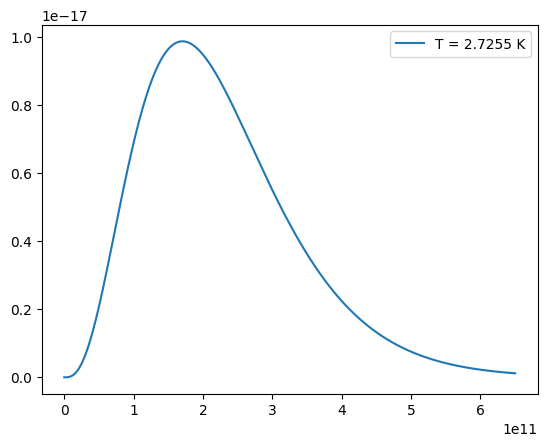

In [29]:
plt.plot(nu, Distribucion, label = 'T = 2.7255 K')
plt.legend()
plt.show()

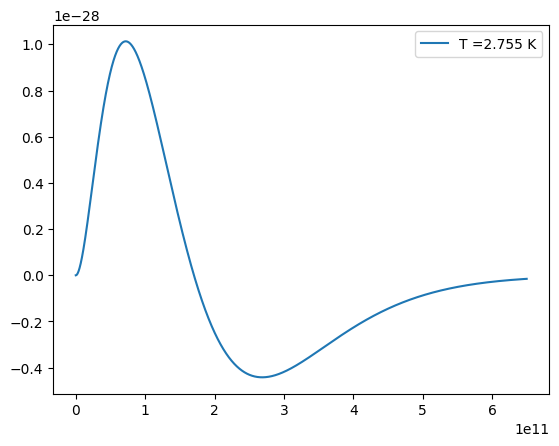

In [34]:
plt.plot(nu, dB, label = 'T =2.755 K')
plt.legend()
plt.show()

In [37]:
from fcl1109 import trapecio
EnergyDensity = trapecio(lambda nu: B(T, nu), 0, np.inf, 10000000)
EnergyDensity

c:\Users\MINEDUCYT\Desktop\Codigo-Manteca\.venv\Lib\site-packages\numpy\_core\function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
C:\Users\MINEDUCYT\AppData\Local\Temp\ipykernel_10160\1955019951.py:4: RuntimeWarning: invalid value encountered in divide
  return  2 * h * nu ** 3 / (c **2 * (np.exp(h * nu / (kB * T) - 1)))


np.float64(nan)

## Ejercicio 6 — Comparación con COBE/FIRAS

El CMB observado es extraordinariamente cercano a un cuerpo negro.

Si tienes disponible el archivo de datos de COBE/FIRAS

`firas_monopole_spec_v1.txt`

puedes comparar los datos con tu espectro de Planck.

El archivo contiene la frecuencia, la intensidad medida y el residuo respecto del cuerpo negro de referencia.

### Actividad

1. Carga los datos.
2. Convierte la frecuencia de $\text{cm}^{-1}$ a GHz.
3. Calcula el espectro de Planck para $T=2.7255$ K.
4. Superpone teoría y datos.
5. Representa por separado los residuos con sus incertidumbres.

### Discusión

Explica por qué el hecho de que el CMB sea tan cercano a un cuerpo negro constituye evidencia de que el Universo temprano estuvo en equilibrio térmico con una precisión extraordinaria.

# V. Electrones y positrones: del régimen relativista al no relativista

Para una especie fermiónica de masa \(m\),

$$
E(p)=\sqrt{p^2c^2+m^2c^4}.
$$

La densidad numérica en equilibrio puede escribirse como

$$
n(T)=
\frac{g}{2\pi^2}
\left(\frac{k_BT}{\hbar c}\right)^3
\int_0^\infty
\frac{x^2\,dx}
{\exp\!\left(\sqrt{x^2+y^2}\right)+1},
$$

donde

$$
x=\frac{pc}{k_BT},
\qquad
y=\frac{mc^2}{k_BT}.
$$

Para electrones y positrones:

$$
g_{e^-}=2,\qquad g_{e^+}=2.
$$

En el límite ultrarrelativista, $y\ll1$, la integral tiende a un valor constante. Cuando $y\gg1$, la abundancia cae exponencialmente.

## Ejercicio 7 — $e^\pm$ frente a fotones

Calcula numéricamente

$$
\frac{n_{e^\pm}}{n_\gamma}
$$

como función de

$$
y=\frac{m_ec^2}{k_BT}.
$$

Para fotones:

$$
n_\gamma=
\frac{2\zeta(3)}{\pi^2}
\left(\frac{k_BT}{\hbar c}\right)^3.
$$

### Entregables

1. Resultado numérico para $n_{e^-}/n_\gamma$.
2. Resultado para $n_{e^+}/n_\gamma$.
3. Comparación con Maxwell–Boltzmann en el régimen $y\gg1$.
4. Gráfica en escala semilogarítmica.

### Pregunta

¿Por qué una partícula puede seguir existiendo como especie fundamental aunque su abundancia térmica de equilibrio sea extremadamente pequeña?

## Ejercicio 8 — Temperatura característica de $e^\pm$

La escala natural para la desaparición térmica de pares es

$$
k_BT\sim m_ec^2.
$$

Usando

$$
m_ec^2=0.511\ {\rm MeV},
$$

calcula

$$
T_{e^\pm}=\frac{m_ec^2}{k_B}.
$$

Después representa

$$
\frac{n_{e^\pm}}{n_\gamma}
$$

en función de $T$.

### Discusión

Explica por qué $T\sim m_e c^2/k_B$ marca una transición importante, pero no significa que la abundancia se vuelva exactamente cero a esa temperatura.

# VI. Grados de libertad relativistas: $g_*$ y $g_{*s}$

Aquí aparece una de las conexiones más importantes con la física estadística.

Para una especie relativista bosónica:

$$
\rho_i=
g_i\frac{\pi^2}{30}T_i^4.
$$

Para una especie relativista fermiónica:

$$
\rho_i=
\frac78 g_i\frac{\pi^2}{30}T_i^4.
$$

Por ello definimos

$$
\boxed{
\rho_R=
\frac{\pi^2}{30}g_*(T)T^4
}.
$$

De forma análoga, la densidad de entropía es

$$
\boxed{
s=
\frac{2\pi^2}{45}g_{*s}(T)T^3
}.
$$

Cuando todas las especies relevantes tienen la misma temperatura,

$$
g_*=g_{*s}.
$$

Cuando algunas especies se desacoplan y dejan de compartir calor, debemos distinguirlos.

## Ejercicio 9 — Construcción de $g_*$

Considera el plasma relativista formado por

- fotones;
- electrones y positrones;
- tres familias de neutrinos y antineutrinos.

Usa:

$$
g_\gamma=2,
$$

$$
g_{e^-}=g_{e^+}=2,
$$

y un total de seis estados de helicidad de neutrinos/antineutrinos.

Construye

$$
g_*=
\sum_{\rm bosones}g_i+
\frac78\sum_{\rm fermiones}g_i.
$$

### Preguntas

1. ¿Cuál es $g_*$ antes de la aniquilación $e^\pm$?
2. ¿Qué sucede con $g_*$ después de la aniquilación?
3. ¿Por qué el factor $7/8$ aparece únicamente para fermiones?
4. ¿Qué cambia si una especie tiene una temperatura $T_i\neq T$?

## Ejercicio 10 — $g_*(T)$ como función de la temperatura

Construye un modelo por tramos para representar la historia simplificada de los grados de libertad:

1. plasma relativista con $e^\pm,\gamma,\nu$;
2. después de la aniquilación $e^\pm$, con neutrinos desacoplados;
3. una extensión opcional hacia temperaturas mucho mayores, donde puedan contribuir más especies del Modelo Estándar.

No se busca reproducir con precisión una tabla de transición QCD: el objetivo es comprender cómo la desaparición térmica de especies modifica $g_*$.

### Figura

Representa $g_*(T)$ frente a $T$ en escala logarítmica.

# VII. Expansión frente a interacciones: $\Gamma/H$

Una especie permanece en equilibrio mientras sus interacciones son suficientemente rápidas frente a la expansión.

La condición esencial es

$$
\boxed{\Gamma(T)\gtrsim H(T)}.
$$

El desacoplamiento ocurre aproximadamente cuando

$$
\boxed{\Gamma(T_{\rm dec})\simeq H(T_{\rm dec})}.
$$

Durante dominación por radiación:

$$
H(T)=
1.66\,g_*^{1/2}
\frac{T^2}{M_{\rm Pl}}.
$$

Para neutrinos, una estimación dimensional de la tasa débil es

$$
\Gamma_\nu(T)\sim G_F^2T^5.
$$

No esperamos una precisión de una simulación de Boltzmann completa: buscamos identificar la escala física correcta.

## Ejercicio 11 — Desacoplamiento de neutrinos

Calcula

$$
\frac{\Gamma_\nu}{H}
$$

como función de \(T\), usando

$$
\Gamma_\nu=G_F^2T^5
$$

y

$$
H=1.66\,g_*^{1/2}\frac{T^2}{M_{\rm Pl}}.
$$

Trabaja en GeV.

### Entregables

1. Gráfica de $\Gamma_\nu/H$.
2. Temperatura aproximada donde $\Gamma_\nu/H=1$.
3. Comparación con la escala esperada de unos pocos MeV.

### Pregunta conceptual

Explica por qué una tasa $\Gamma\propto T^5$ hace que el equilibrio se pierda rápidamente cuando el Universo se enfría.

# VIII. Entropía y temperatura de los neutrinos

Después del desacoplamiento de neutrinos:

$$
T_\nu\propto a^{-1}.
$$

Los electrones y positrones, sin embargo, permanecen temporalmente acoplados al plasma electromagnético y al aniquilarse transfieren entropía a los fotones.

La conservación de entropía del plasma electromagnético da

$$
g_{*s}^{\rm antes}T_{\gamma,\rm antes}^3
=
g_{*s}^{\rm después}T_{\gamma,\rm después}^3.
$$

Antes de la aniquilación:

$$
g_{*s}^{\rm antes}
=
2+\frac78(4)=\frac{11}{2}.
$$

Después:

$$
g_{*s}^{\rm después}=2.
$$

Por tanto,

$$
\boxed{
\frac{T_\nu}{T_\gamma}
=
\left(\frac4{11}\right)^{1/3}
}.
$$

## Ejercicio 12 — Derivación numérica de $T_\nu/T_\gamma$

1. Calcula $g_{*s}^{\rm antes}$.
2. Calcula $g_{*s}^{\rm después}$.
3. Obtén numéricamente $T_\nu/T_\gamma$.
4. Calcula $T_\nu$ actual suponiendo $T_\gamma=2.7255$ K.
5. Explica por qué esta relación no sería correcta si los neutrinos permanecieran en equilibrio con los fotones durante toda la aniquilación $e^\pm$.

# IX. Equilibrio neutrón–protón

Las interacciones débiles mantienen aproximadamente:

$$
n+\nu_e\leftrightarrow p+e^-,
$$

$$
n+e^+\leftrightarrow p+\bar\nu_e.
$$

En equilibrio:

$$
\frac{n_n}{n_p}
\simeq
\exp\left(-\frac{\Delta m c^2}{k_BT}\right),
$$

con

$$
\Delta m c^2\simeq1.293\ {\rm MeV}.
$$

La fracción de neutrones es

$$
q(T)=
\frac{n_n}{n_n+n_p}
=
\frac{1}{1+\exp(\Delta m c^2/k_BT)}.
$$

Esta expresión permite pasar directamente de una diferencia microscópica de masas a una cantidad relevante para la nucleosíntesis.

## Ejercicio 13 — $q(T)$ en equilibrio

Grafica $q(T)$ para

$$
10^9\ {\rm K}<T<10^{11.5}\ {\rm K}.
$$

Marca una temperatura característica

$$
T_{\rm np}=1.5\times10^{10}\ {\rm K}
$$

y calcula $q(T_{\rm np})$.

### Preguntas

1. ¿Qué ocurre con $q$ cuando $T\gg\Delta m c^2/k_B$?
2. ¿Qué ocurre cuando $T\ll\Delta m c^2/k_B$?
3. ¿Por qué $q\to1/2$ a temperaturas muy altas?
4. ¿Por qué la fracción de neutrones disminuye cuando el Universo se enfría?

# X. De la temperatura al tiempo cósmico

Durante la dominación por radiación:

$$
H\simeq\frac{1}{2t}.
$$

Combinando esto con

$$
H=
1.66g_*^{1/2}\frac{T^2}{M_{\rm Pl}},
$$

obtenemos

$$
\boxed{
t(T)\simeq
0.301\,g_*^{-1/2}
\frac{M_{\rm Pl}}{T^2}
}
$$

en unidades naturales.

Usando

$$
1\ {\rm GeV}^{-1}
=
6.582119569\times10^{-25}\ {\rm s},
$$

podemos transformar el resultado a segundos.

## Ejercicio 14 — $t(T)$

Construye $t(T)$ para

$$
0.01\ {\rm MeV}<T<100\ {\rm MeV}.
$$

Verifica que para

$$
T\simeq1\ {\rm MeV}
$$

el tiempo cósmico sea del orden de un segundo.

### Preguntas

1. ¿Por qué el Universo era mucho más joven a temperaturas mayores?
2. ¿Qué papel desempeña $g_*$ en la relación $t(T)$?
3. ¿Por qué no debemos utilizar esta fórmula sin cuidado cuando $g_*(T)$ cambia bruscamente?

## Ejercicio 15 — Después del congelamiento: decaimiento de neutrones

Una vez que las interacciones débiles dejan de mantener el equilibrio, podemos modelar de manera simplificada el decaimiento de neutrones mediante

$$
n\rightarrow p+e^-+\bar\nu_e
$$

y

$$
q(t)=q_f\exp\left[-\frac{t-t_f}{\tau_n}\right],
$$

donde

$$
\tau_n\simeq880\ {\rm s}.
$$

Usa como temperatura de congelamiento una escala de

$$
T_f\simeq0.8\ {\rm MeV}
$$

y calcula $q_f$ a partir de la expresión de equilibrio.

Después evoluciona $q$ hasta

$$
T_{\rm BBN}\simeq0.07\ {\rm MeV}.
$$

### Importante

Esto es un **modelo simplificado**. Una predicción precisa de nucleosíntesis requiere una red nuclear y una evolución más completa de las tasas débiles.

# XI. Nucleosíntesis primordial: del $n/p$ al helio

La mayor parte de los neutrones disponibles al comenzar la nucleosíntesis terminan incorporándose en núcleos de helio-4.

En una aproximación muy sencilla, si $q_{\rm BBN}$ es la fracción de neutrones,

$$
q_{\rm BBN}
=
\frac{n_n}{n_n+n_p},
$$

la fracción de masa de helio-4 puede estimarse mediante

$$
\boxed{
Y_p\simeq2q_{\rm BBN}
}.
$$

La razón del factor 2 es que cada núcleo de $^4{\rm He}$ contiene dos neutrones y cuatro nucleones.

## Ejercicio 16 — Estimación de \(Y_p\)

Usa el valor de $q$ obtenido al final del ejercicio anterior para estimar

$$
Y_p.
$$

### Análisis de sensibilidad

Repite el cálculo variando:

- $T_f$ entre $0.7$ y $1.0$ MeV;
- $\tau_n$ entre $870$ y $890$ s.

Construye una gráfica de $Y_p$ frente a $T_f$.

### Pregunta

¿Por qué una pequeña variación de la fracción de neutrones puede tener consecuencias observables sobre la abundancia primordial de helio?

# 📚 Referencias

- S. Dodelson & F. Schmidt, *Modern Cosmology*.
- E. W. Kolb & M. S. Turner, *The Early Universe*.
- V. Mukhanov, *Physical Foundations of Cosmology*.
- S. Weinberg, *Cosmology*.
- P. J. E. Peebles, *Principles of Physical Cosmology*.
- NASA/LAMBDA, productos de datos de COBE/FIRAS.

